In [39]:
import pandas as pd
data = pd.read_csv('FinalRMdata.csv')

In [40]:
data.head()
data = data.drop(columns='Unnamed: 0')

In [22]:
data.isnull().sum()

Y      0
X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
dtype: int64

In [8]:
corr_matrix = data.corr()

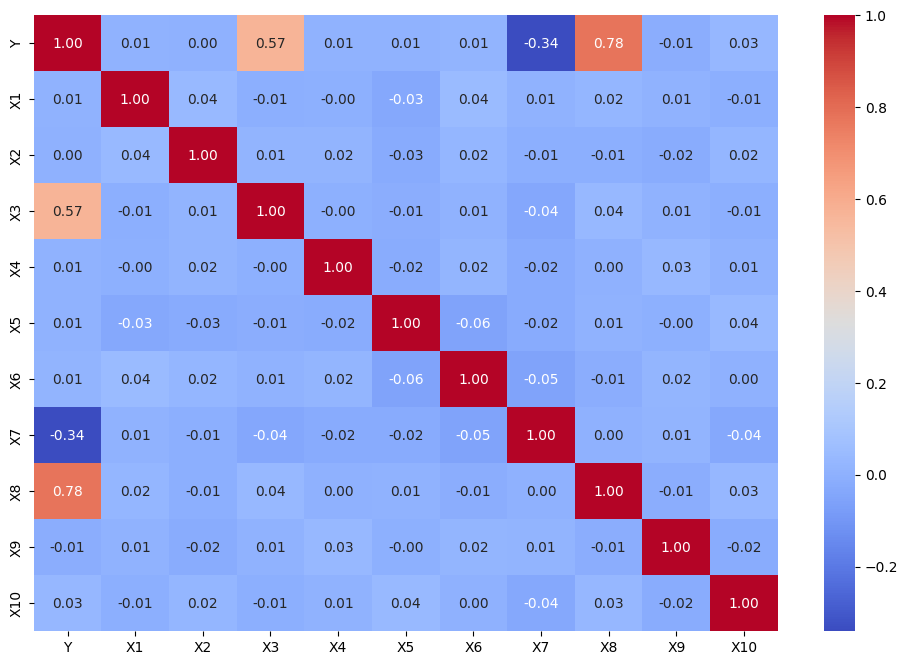

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.heatmap(corr_matrix, annot = True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.show()

plt.subplot(1, 3, 2)

plt.subplot(1, 3, ˇˇ)

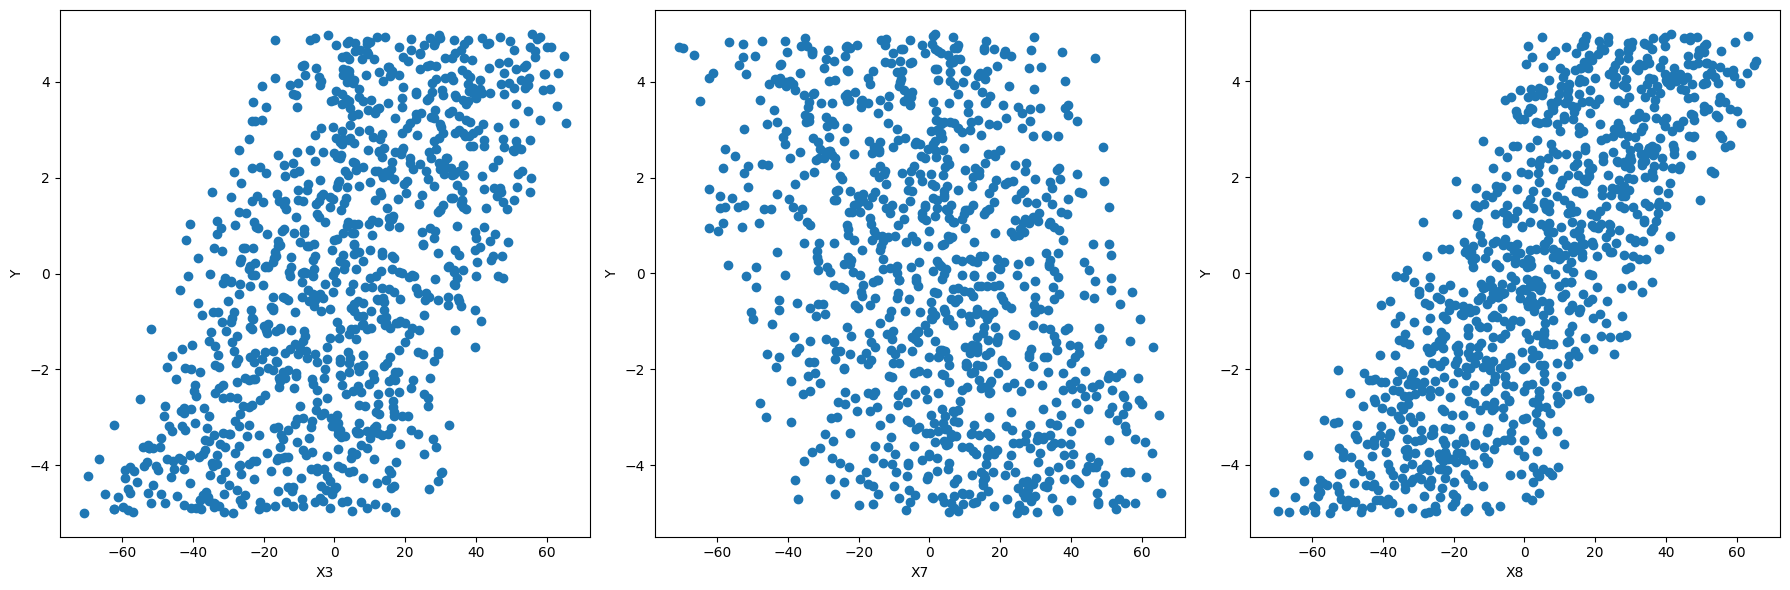

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.xlabel('X3')
plt.ylabel('Y')
plt.scatter(data['Y'], data['X3'])

plt.subplot(1, 3, 2)
plt.xlabel('X7')
plt.ylabel('Y')
plt.scatter(data['Y'], data['X7'])

plt.subplot(1, 3, 3)
plt.xlabel('X8')
plt.ylabel('Y')
plt.scatter(data['Y'], data['X8'])

plt.tight_layout()
plt.show()

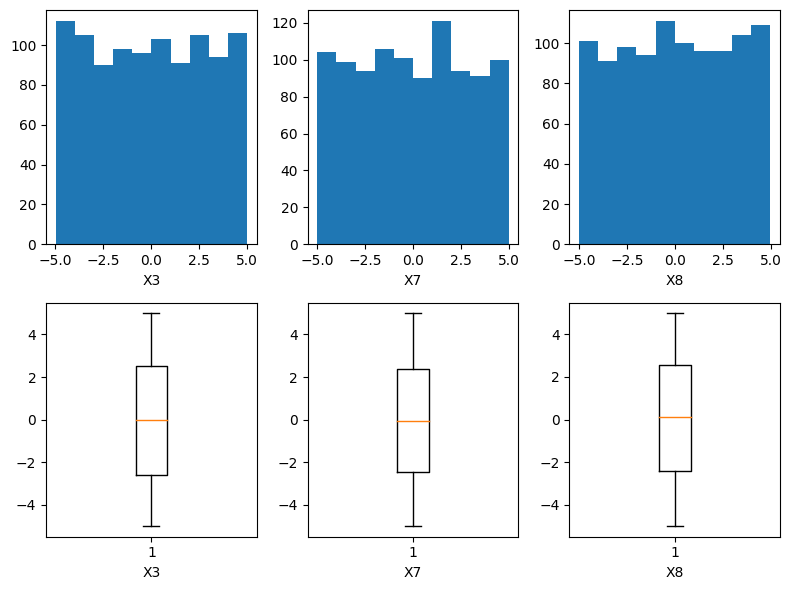

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.subplot(2, 3, 1)
plt.xlabel('X3')
plt.hist(data['X3'])
plt.subplot(2, 3, 4)
plt.xlabel('X3')
plt.boxplot(data['X3'])

plt.subplot(2, 3, 2)
plt.xlabel('X7')
plt.hist(data['X7'])
plt.subplot(2, 3, 5)
plt.xlabel('X7')
plt.boxplot(data['X7'])

plt.subplot(2, 3, 3)
plt.xlabel('X8')
plt.hist(data['X8'])
plt.subplot(2, 3, 6)
plt.xlabel('X8')
plt.boxplot(data['X8'])

plt.tight_layout()
plt.show()

In [43]:
import statsmodels.api as sm
X1 = data[['X3', 'X7', 'X8']]
X1 = sm.add_constant(X1)
y = data['Y']

model1 = sm.OLS(y, X1).fit()
model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 2.754e+05
Date:                Wed, 01 Jan 2025   Prob (F-statistic):               0.00
Time:                        03:16:38   Log-Likelihood:                -1377.2
No. Observations:                1000   AIC:                             2762.
Df Residuals:                     996   BIC:                             2782.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0101      0.030     66.120      0.000       1.950       2.070
X3             4.9989      0.010    482.692      0.000       4.979       5.019
X7            -3.0952      0.011   -292.295      0.000      -3.116      -3.074
X8             7.2121      0.010    687.409      0.000       7.191       7.233
==============================================================================
Omnibus:                        2.991   Durbin-Watson:                   2.017
Prob(Omnibus):                  0.224   Jarque-Bera (JB):                2.880
Skew:                          -0.101   Prob(JB):                        0.237
Kurtosis:                       3.168   Cond. No.                         2.99
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

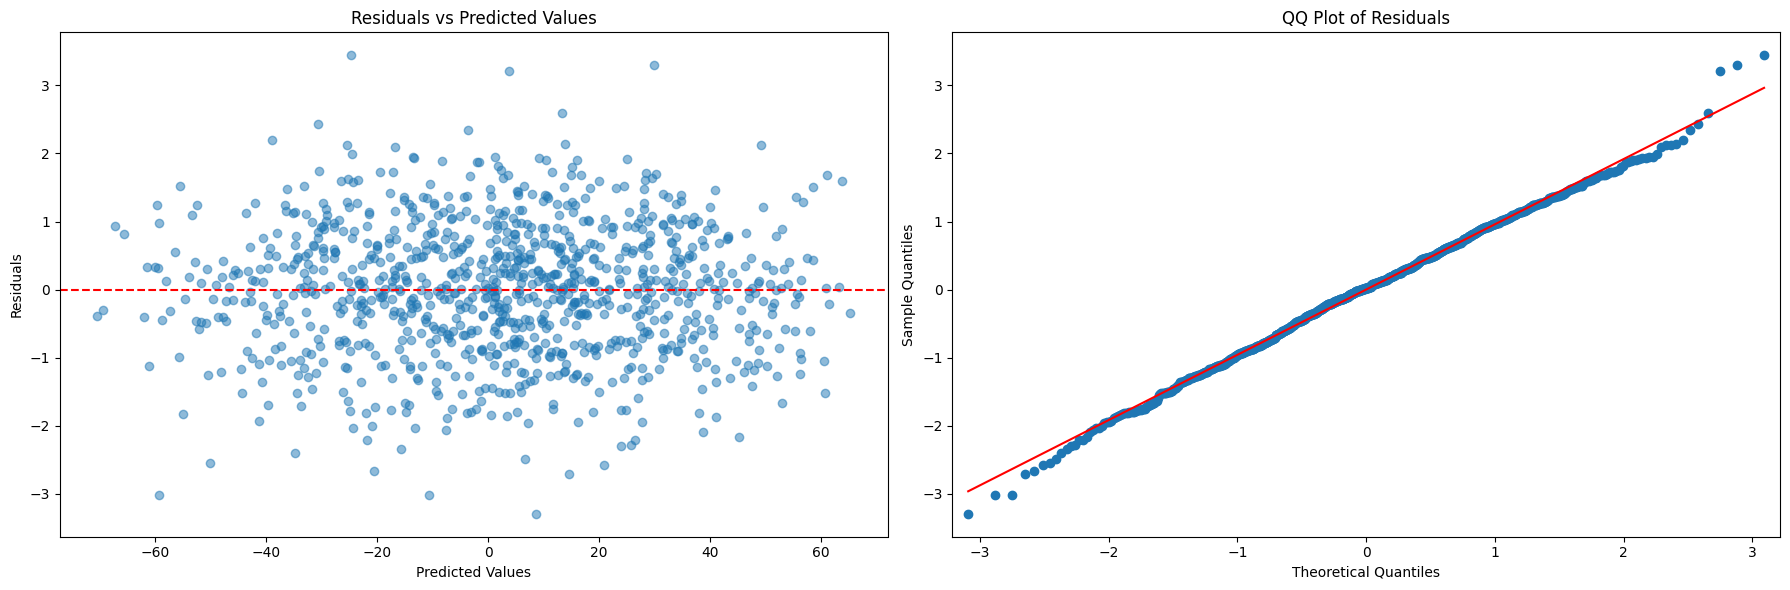

In [47]:
# 重新載入必要的程式庫與資料
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot
import statsmodels.api as sm



plt.figure(figsize=(18, 6))

predictions = model1.predict(X1)
residuals = y - predictions

plt.subplot(1, 2, 1)
plt.scatter(predictions, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
qqplot(residuals, line='s', ax=plt.gca())
plt.title('QQ Plot of Residuals')

# 顯示圖形
plt.tight_layout()
plt.show()


In [49]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X1.columns
vif_data["VIF"] = [variance_inflation_factor(X1.values, i) for i in range(X1.shape[1])]
vif_data

,Variable,VIF
0,const,1.000733
1,X3,1.002647
2,X7,1.001376
3,X8,1.001274


In [50]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


# 分割資料為訓練集與測試集 (80% 訓練，20% 測試)
X_train, X_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=42)

# 初始化線性回歸模型
model = LinearRegression()

# 交叉驗證 (10-fold)
cross_val_scores = cross_val_score(model, X_train, y_train, cv=10, scoring='r2')

# 在訓練集上擬合模型
model.fit(X_train, y_train)

# 在測試集上進行預測
y_pred = model.predict(X_test)

# 計算測試集上的 R^2
test_r2 = r2_score(y_test, y_pred)

# 結果整理
results = {
    "Cross-Validation R^2 Scores": cross_val_scores.tolist(),
    "Mean CV R^2": cross_val_scores.mean(),
    "Test Set R^2": test_r2
}

results

{'Cross-Validation R^2 Scores': [0.9984501964632381,
  0.9982177048127583,
  0.9987126434895293,
  0.998877311654662,
  0.9988260454898403,
  0.9989179031279888,
  0.9986579478713161,
  0.9985785973665832,
  0.9989497636144868,
  0.9992111724261391],
 'Mean CV R^2': 0.9987399286316542,
 'Test Set R^2': 0.9988039931547882}

In [54]:
import numpy as np

# 提取模型的回歸係數
coefficients = model.coef_  # 回歸係數
intercept = model.intercept_  # 截距

# 固定策略的已知值
X3_val = 7
X7_val = 5

# 計算 X8 的範圍
X8_min = X1['X8'].min()
X8_max = X1['X8'].max()

# 計算可能的回報範圍
Y_min = intercept + coefficients[0] * X3_val + coefficients[1] * X7_val + coefficients[2] * X8_min
Y_max = intercept + coefficients[0] * X3_val + coefficients[1] * X7_val + coefficients[2] * X8_max


# 整理結果
possible_returns = {
    "X3": X3_val,
    "X7": X7_val,
    "X8_min": X8_min,
    "X8_max": X8_max,
    "Y_min": Y_min,
    "Y_max": Y_max
}

possible_returns

{'X3': 7,
 'X7': 5,
 'X8_min': -4.99978886451572,
 'X8_max': 4.99104328686371,
 'Y_min': 42.417885919354426,
 'Y_max': 11.629491414621453}

In [59]:
# 計算 X8 的平均值
X8_mean = X1['X8'].mean()

# 計算回報範圍與平均回報
Y_mean = intercept + coefficients[0] * X3_val + coefficients[1] * X7_val + coefficients[2] * X8_mean

# 整理結果，包括 X8 的最小值、最大值、平均值和對應回報
extended_results = pd.DataFrame([{
    "X3": X3_val,
    "X7": X7_val,
    "X8_min": X8_min,
    "X8_max": X8_max,
    "Y_min": Y_min,
    "Y_max": Y_max,
}])
extended_results



,X3,X7,X8_min,X8_max,Y_min,Y_max
0,7,5,-4.999789,4.991043,42.417886,11.629491


In [46]:
import statsmodels.api as sm
X2 = data[['X3', 'X8']]
X2 = sm.add_constant(X2)
y = data['Y']

model2 = sm.OLS(y, X2).fit()
model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.896
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                     4272.
Date:                Wed, 01 Jan 2025   Prob (F-statistic):               0.00
Time:                        03:17:33   Log-Likelihood:                -3608.9
No. Observations:                1000   AIC:                             7224.
Df Residuals:                     997   BIC:                             7238.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1418      0.283      7.567      0.000       1.586       2.697
X3             5.1111      0.096     53.042      0.000       4.922       5.300
X8             7.2060      0.098     73.767      0.000       7.014       7.398
==============================================================================
Omnibus:                      443.775   Durbin-Watson:                   2.060
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               53.108
Skew:                          -0.007   Prob(JB):                     2.94e-12
Kurtosis:                       1.871   Cond. No.                         2.97
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""